<a href="https://colab.research.google.com/github/24Sinchana/project/blob/main/ML%20PROJECTS/Dog_vs_Cat_25GB_RAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# New Section

In [66]:
#Dog vs Cat classifictaion using Transfer learning
#we use MobileNet model

In [67]:
!pip install kaggle

In [68]:
# configuring the path of Kaggle.json file
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [69]:
!kaggle competitions download -c dogs-vs-cats

dogs-vs-cats.zip: Skipping, found more recently modified local copy (use --force to force download)


In [70]:
!ls

 dogs-vs-cats.zip   kaggle.json   sampleSubmission.csv	 train
'image resized'     sample_data   test1.zip		 train.zip


In [71]:
# extracting the compressed dataset
from zipfile import ZipFile

dataset = '/content/dogs-vs-cats.zip'

with ZipFile(dataset, 'r') as zip:
  zip.extractall()
  print('The dataset is extracted')

The dataset is extracted


In [72]:
# extracting the compressed dataset
from zipfile import ZipFile

dataset = '/content/train.zip'

with ZipFile(dataset, 'r') as zip:
  zip.extractall()
  print('The dataset is extracted')

The dataset is extracted


In [73]:
import os
# counting the number of files in train folder
path, dirs, files = next(os.walk('/content/train'))
file_count = len(files)
print('Number of images: ', file_count)

Number of images:  25000


In [74]:
file_names = os.listdir('/content/train/') #list all the files in directory
print(file_names)

['cat.3653.jpg', 'dog.2057.jpg', 'dog.7985.jpg', 'cat.5015.jpg', 'cat.1452.jpg', 'cat.10751.jpg', 'cat.8565.jpg', 'cat.3194.jpg', 'dog.11472.jpg', 'cat.4086.jpg', 'dog.10364.jpg', 'cat.8073.jpg', 'cat.3468.jpg', 'cat.4003.jpg', 'dog.2628.jpg', 'cat.10182.jpg', 'dog.4553.jpg', 'dog.11425.jpg', 'cat.8167.jpg', 'cat.6104.jpg', 'cat.12254.jpg', 'dog.654.jpg', 'dog.1811.jpg', 'dog.11664.jpg', 'dog.5952.jpg', 'cat.8733.jpg', 'cat.54.jpg', 'cat.3540.jpg', 'cat.2098.jpg', 'dog.6602.jpg', 'dog.5730.jpg', 'cat.9094.jpg', 'cat.9063.jpg', 'dog.4692.jpg', 'dog.172.jpg', 'cat.7095.jpg', 'dog.9353.jpg', 'dog.6084.jpg', 'dog.6055.jpg', 'cat.1583.jpg', 'cat.8187.jpg', 'dog.3911.jpg', 'dog.11429.jpg', 'dog.3749.jpg', 'cat.6767.jpg', 'dog.9918.jpg', 'dog.7645.jpg', 'cat.12231.jpg', 'cat.3248.jpg', 'dog.6173.jpg', 'dog.1584.jpg', 'dog.10378.jpg', 'cat.6872.jpg', 'dog.7193.jpg', 'cat.11506.jpg', 'cat.11016.jpg', 'cat.10776.jpg', 'dog.3107.jpg', 'dog.10647.jpg', 'dog.6621.jpg', 'cat.4342.jpg', 'dog.2027.jpg

In [75]:
import numpy as np
from PIL import Image  # used in image processing  projects
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from sklearn.model_selection import train_test_split
from google.colab.patches import cv2_imshow  # to display images


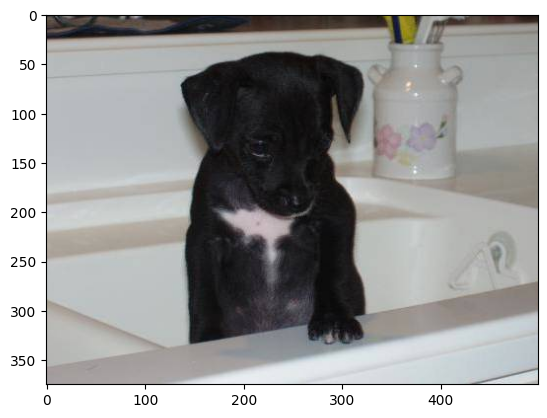

In [76]:
# display dog image
img = mpimg.imread('/content/train/dog.8298.jpg')
imgplt = plt.imshow(img)
plt.show()

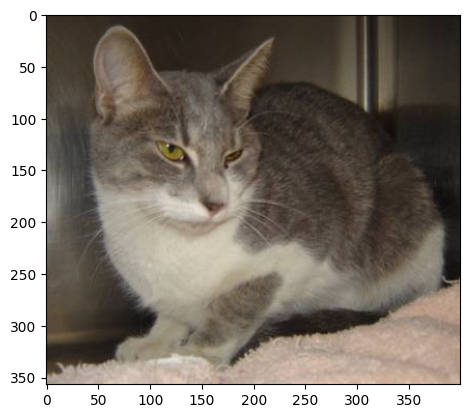

In [77]:
# display cat image
img = mpimg.imread('/content/train/cat.4352.jpg')
imgplt = plt.imshow(img)
plt.show()

In [78]:
file_names = os.listdir('/content/train')

dog_count=0
cat_count=0

for img_file in file_names:
   name = img_file[0:3]  #first three letters of image name

   if name == 'dog':
    dog_count += 1

   else:
     cat_count += 1

print("Number of dog images:", dog_count)
print('Number of cat images:', cat_count)

Number of dog images: 12500
Number of cat images: 12500


In [79]:
import os
from PIL import Image

original_folder = '/content/train/'
resized_folder = '/content/image resized/'

# Create the resized folder if it doesn't exist
if not os.path.exists(resized_folder):
    os.makedirs(resized_folder)

for filename in os.listdir(original_folder):
    if filename.startswith(('dog', 'cat')):  # Process both dog and cat images
        img_path = os.path.join(original_folder, filename)

        try:
            img = Image.open(img_path)
            img = img.resize((224, 224))
            img = img.convert('RGB')

            new_img_path = os.path.join(resized_folder, filename)
            img.save(new_img_path)
            # print(f"Resized and saved: {filename}")  # Optional: Print progress
        except Exception as e:
            print(f"Error processing {filename}: {e}")

print("Resizing completed.")

Resizing completed.


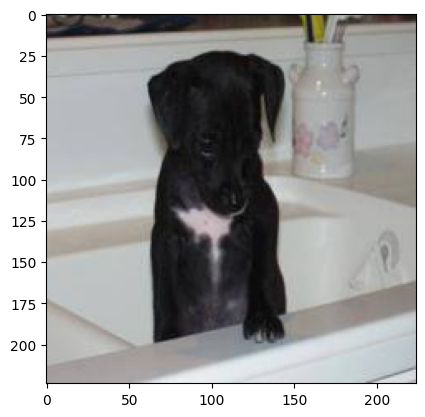

In [80]:
# display resized dog image
img = mpimg.imread('/content/image resized/dog.8298.jpg')
imgplt = plt.imshow(img)
plt.show()

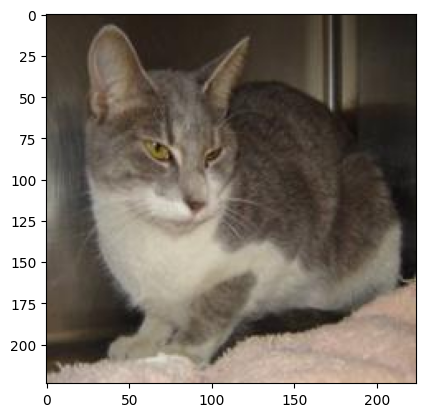

In [81]:
#resize cat image
img = mpimg.imread('/content/image resized/cat.4352.jpg')
imgplt = plt.imshow(img)
plt.show()

In [82]:
#creating for loop to assign labels'
filenames=os.listdir('/content/image resized/')
labels=[]

for i in range(25000):

  file_name=filenames[i]
  label=file_name[0:3] #first three letter of file name

  if label=='dog': #sliced string
    labels.append(1)

  else:
    labels.append(0)

In [83]:
#print first five
print(filenames[0:5])
print(len(filenames))
print(labels[0:5])


['cat.3653.jpg', 'dog.2057.jpg', 'dog.7985.jpg', 'cat.5015.jpg', 'cat.1452.jpg']
25000
[0, 1, 1, 0, 0]


In [84]:
#counting images of dogs and cats out of 25000
values,counts = np.unique(labels, return_counts = True) #unique values
print(values,counts)

[0 1] [12500 12500]


In [85]:
#Convert all the images to numpy array(extract pixel values)
import cv2
import glob

In [86]:
# Convert all the images to numpy array (extract pixel values)
image_directory = '/content/image resized/'
image_extension= ['png','jpg']
#chcek if the image is in png or jpg and then convert it to numparray

files=[]

[files.extend(glob.glob(image_directory +'*.' + e))for e in image_extension ]
#iterate through png and jpg
#locate the file

dog_cat_images = np.asarray([cv2.imread(file) for file in files]) #read image and

In [87]:
print(dog_cat_images)

[[[[ 46  40  41]
   [ 46  40  41]
   [ 46  40  41]
   ...
   [ 43  37  38]
   [ 43  37  38]
   [ 43  37  38]]

  [[ 46  40  41]
   [ 46  40  41]
   [ 46  40  41]
   ...
   [ 43  37  38]
   [ 43  37  38]
   [ 43  37  38]]

  [[ 46  40  41]
   [ 46  40  41]
   [ 46  40  41]
   ...
   [ 43  37  38]
   [ 43  37  38]
   [ 43  37  38]]

  ...

  [[ 57  51  56]
   [ 45  39  44]
   [ 32  28  33]
   ...
   [ 60  62  86]
   [ 66  67  88]
   [ 70  71  92]]

  [[ 52  46  51]
   [ 41  35  40]
   [ 29  25  30]
   ...
   [ 57  60  81]
   [ 64  65  86]
   [ 70  68  90]]

  [[ 48  42  47]
   [ 38  32  37]
   [ 27  23  28]
   ...
   [ 54  57  78]
   [ 62  60  82]
   [ 66  64  86]]]


 [[[ 94  93 137]
   [ 93  92 136]
   [ 99  98 142]
   ...
   [ 86  88  99]
   [ 80  83  97]
   [ 79  85  98]]

  [[ 95  94 138]
   [ 93  92 136]
   [ 99  98 142]
   ...
   [ 85  87  98]
   [ 81  84  98]
   [ 80  86  99]]

  [[ 96  95 139]
   [ 93  92 136]
   [ 98  97 141]
   ...
   [ 82  84  95]
   [ 79  82  96]
   [ 79  84

In [88]:
type(dog_cat_images)
print(dog_cat_images.shape)

(25000, 224, 224, 3)


In [89]:
X=dog_cat_images
Y=np.asarray(labels)

In [90]:
# Ensure X and Y have the same number of samples
X = dog_cat_images[:len(labels)]  # Truncate X to match the length of Y
Y = np.asarray(labels)

In [91]:
#creating train test split
import numpy as np
from sklearn.model_selection import train_test_split

# Assuming X and Y are your original data and labels
num_samples_to_keep = 2000

# Randomly select indices for the reduced dataset
selected_indices = np.random.choice(len(X), num_samples_to_keep, replace=False)

# Create the reduced dataset
X_reduced = X[selected_indices]
Y_reduced = Y[selected_indices]

# Now you can use X_reduced and Y_reduced for training
X_train, X_test, Y_train, Y_test = train_test_split(X_reduced, Y_reduced, test_size=0.2, random_state=2)



print(X_reduced.shape)
print(Y_reduced.shape)

(2000, 224, 224, 3)
(2000,)


In [103]:
print("Number of samples in X:", len(X_reduced))
print("Number of samples in Y:", len(Y_reduced))

Number of samples in X: 2000
Number of samples in Y: 2000


In [104]:
X_train_scaled = X_train/255
Xtest_scaled = X_test/255

In [94]:
print(X_train_scaled)

[[[[0.69019608 0.6745098  0.67058824]
   [0.70196078 0.68627451 0.68235294]
   [0.70980392 0.69411765 0.69019608]
   ...
   [0.74509804 0.6627451  0.67058824]
   [0.7372549  0.65098039 0.65882353]
   [0.7254902  0.63921569 0.64705882]]

  [[0.70196078 0.68627451 0.68235294]
   [0.71372549 0.69803922 0.69411765]
   [0.7254902  0.70980392 0.70588235]
   ...
   [0.76470588 0.68235294 0.69019608]
   [0.76078431 0.67843137 0.68627451]
   [0.75294118 0.67058824 0.67843137]]

  [[0.71372549 0.69803922 0.69411765]
   [0.72941176 0.71372549 0.70980392]
   [0.74117647 0.7254902  0.72156863]
   ...
   [0.76078431 0.69019608 0.69411765]
   [0.76470588 0.69411765 0.69803922]
   [0.76470588 0.69411765 0.69803922]]

  ...

  [[1.         1.         0.98431373]
   [0.96078431 0.96078431 0.9372549 ]
   [0.94117647 0.9254902  0.92156863]
   ...
   [0.70980392 0.7254902  0.70588235]
   [0.70588235 0.71764706 0.70980392]
   [0.70980392 0.7254902  0.70588235]]

  [[1.         1.         0.96862745]
   [0.9

In [95]:
import tensorflow as tf
from tensorflow import keras
import tensorflow_hub as hub

mobilenet_model = 'https://tfhub.dev/google/tf2-preview/mobilenet_v2/feature_vector/4'

pretrained_model = hub.KerasLayer(mobilenet_model, input_shape=(224,224,3), trainable=False)



In [96]:
!pip install tf_keras
import tf_keras

num_of_classes = 2

model = tf_keras.Sequential([

    pretrained_model,
    tf_keras.layers.Dense(num_of_classes)

])

model.summary()


Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 keras_layer_4 (KerasLayer)  (None, 1280)              2257984   
                                                                 
 dense_3 (Dense)             (None, 2)                 2562      
                                                                 
Total params: 2260546 (8.62 MB)
Trainable params: 2562 (10.01 KB)
Non-trainable params: 2257984 (8.61 MB)
_________________________________________________________________


In [97]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),  # Use tf.keras.losses.SparseCategoricalCrossentropy
    metrics=['acc']
)

In [98]:
model.fit(X_train_scaled, Y_train, epochs=5, batch_size=32) # Or even smaller batch_size like 16

Epoch 1/5
50/50 [==============================] - 77s 1s/step - loss: 0.1835 - acc: 0.9287
Epoch 2/5
50/50 [==============================] - 71s 1s/step - loss: 0.0679 - acc: 0.9756
Epoch 3/5
50/50 [==============================] - 72s 1s/step - loss: 0.0507 - acc: 0.9844
Epoch 4/5
50/50 [==============================] - 70s 1s/step - loss: 0.0411 - acc: 0.9862
Epoch 5/5
50/50 [==============================] - 69s 1s/step - loss: 0.0318 - acc: 0.9912


In [100]:
score, acc = model.evaluate(Xtest_scaled , Y_test)
print('Test Loss =', score)
print('Test Accuracy =', acc)

13/13 [==============================] - 19s 1s/step - loss: 0.0559 - acc: 0.9850
Test Loss = 0.055870845913887024
Test Accuracy = 0.9850000143051147


Path of the image to be predicted: /content/dog.jpg


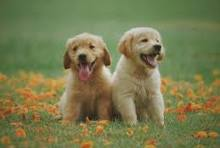

1/1 [==============================] - 0s 465ms/step
[[-4.1138196  3.450454 ]]
1
The image represents a Dog


In [101]:
input_image_path = input('Path of the image to be predicted: ')

input_image = cv2.imread(input_image_path)

cv2_imshow(input_image)

input_image_resize = cv2.resize(input_image, (224,224))

input_image_scaled = input_image_resize/255

image_reshaped = np.reshape(input_image_scaled, [1,224,224,3])

input_prediction = model.predict(image_reshaped)

print(input_prediction)

input_pred_label = np.argmax(input_prediction)

print(input_pred_label)

if input_pred_label == 0:
  print('The image represents a Cat')

else:
  print('The image represents a Dog')

Path of the image to be predicted: /content/kitty cat.jpg


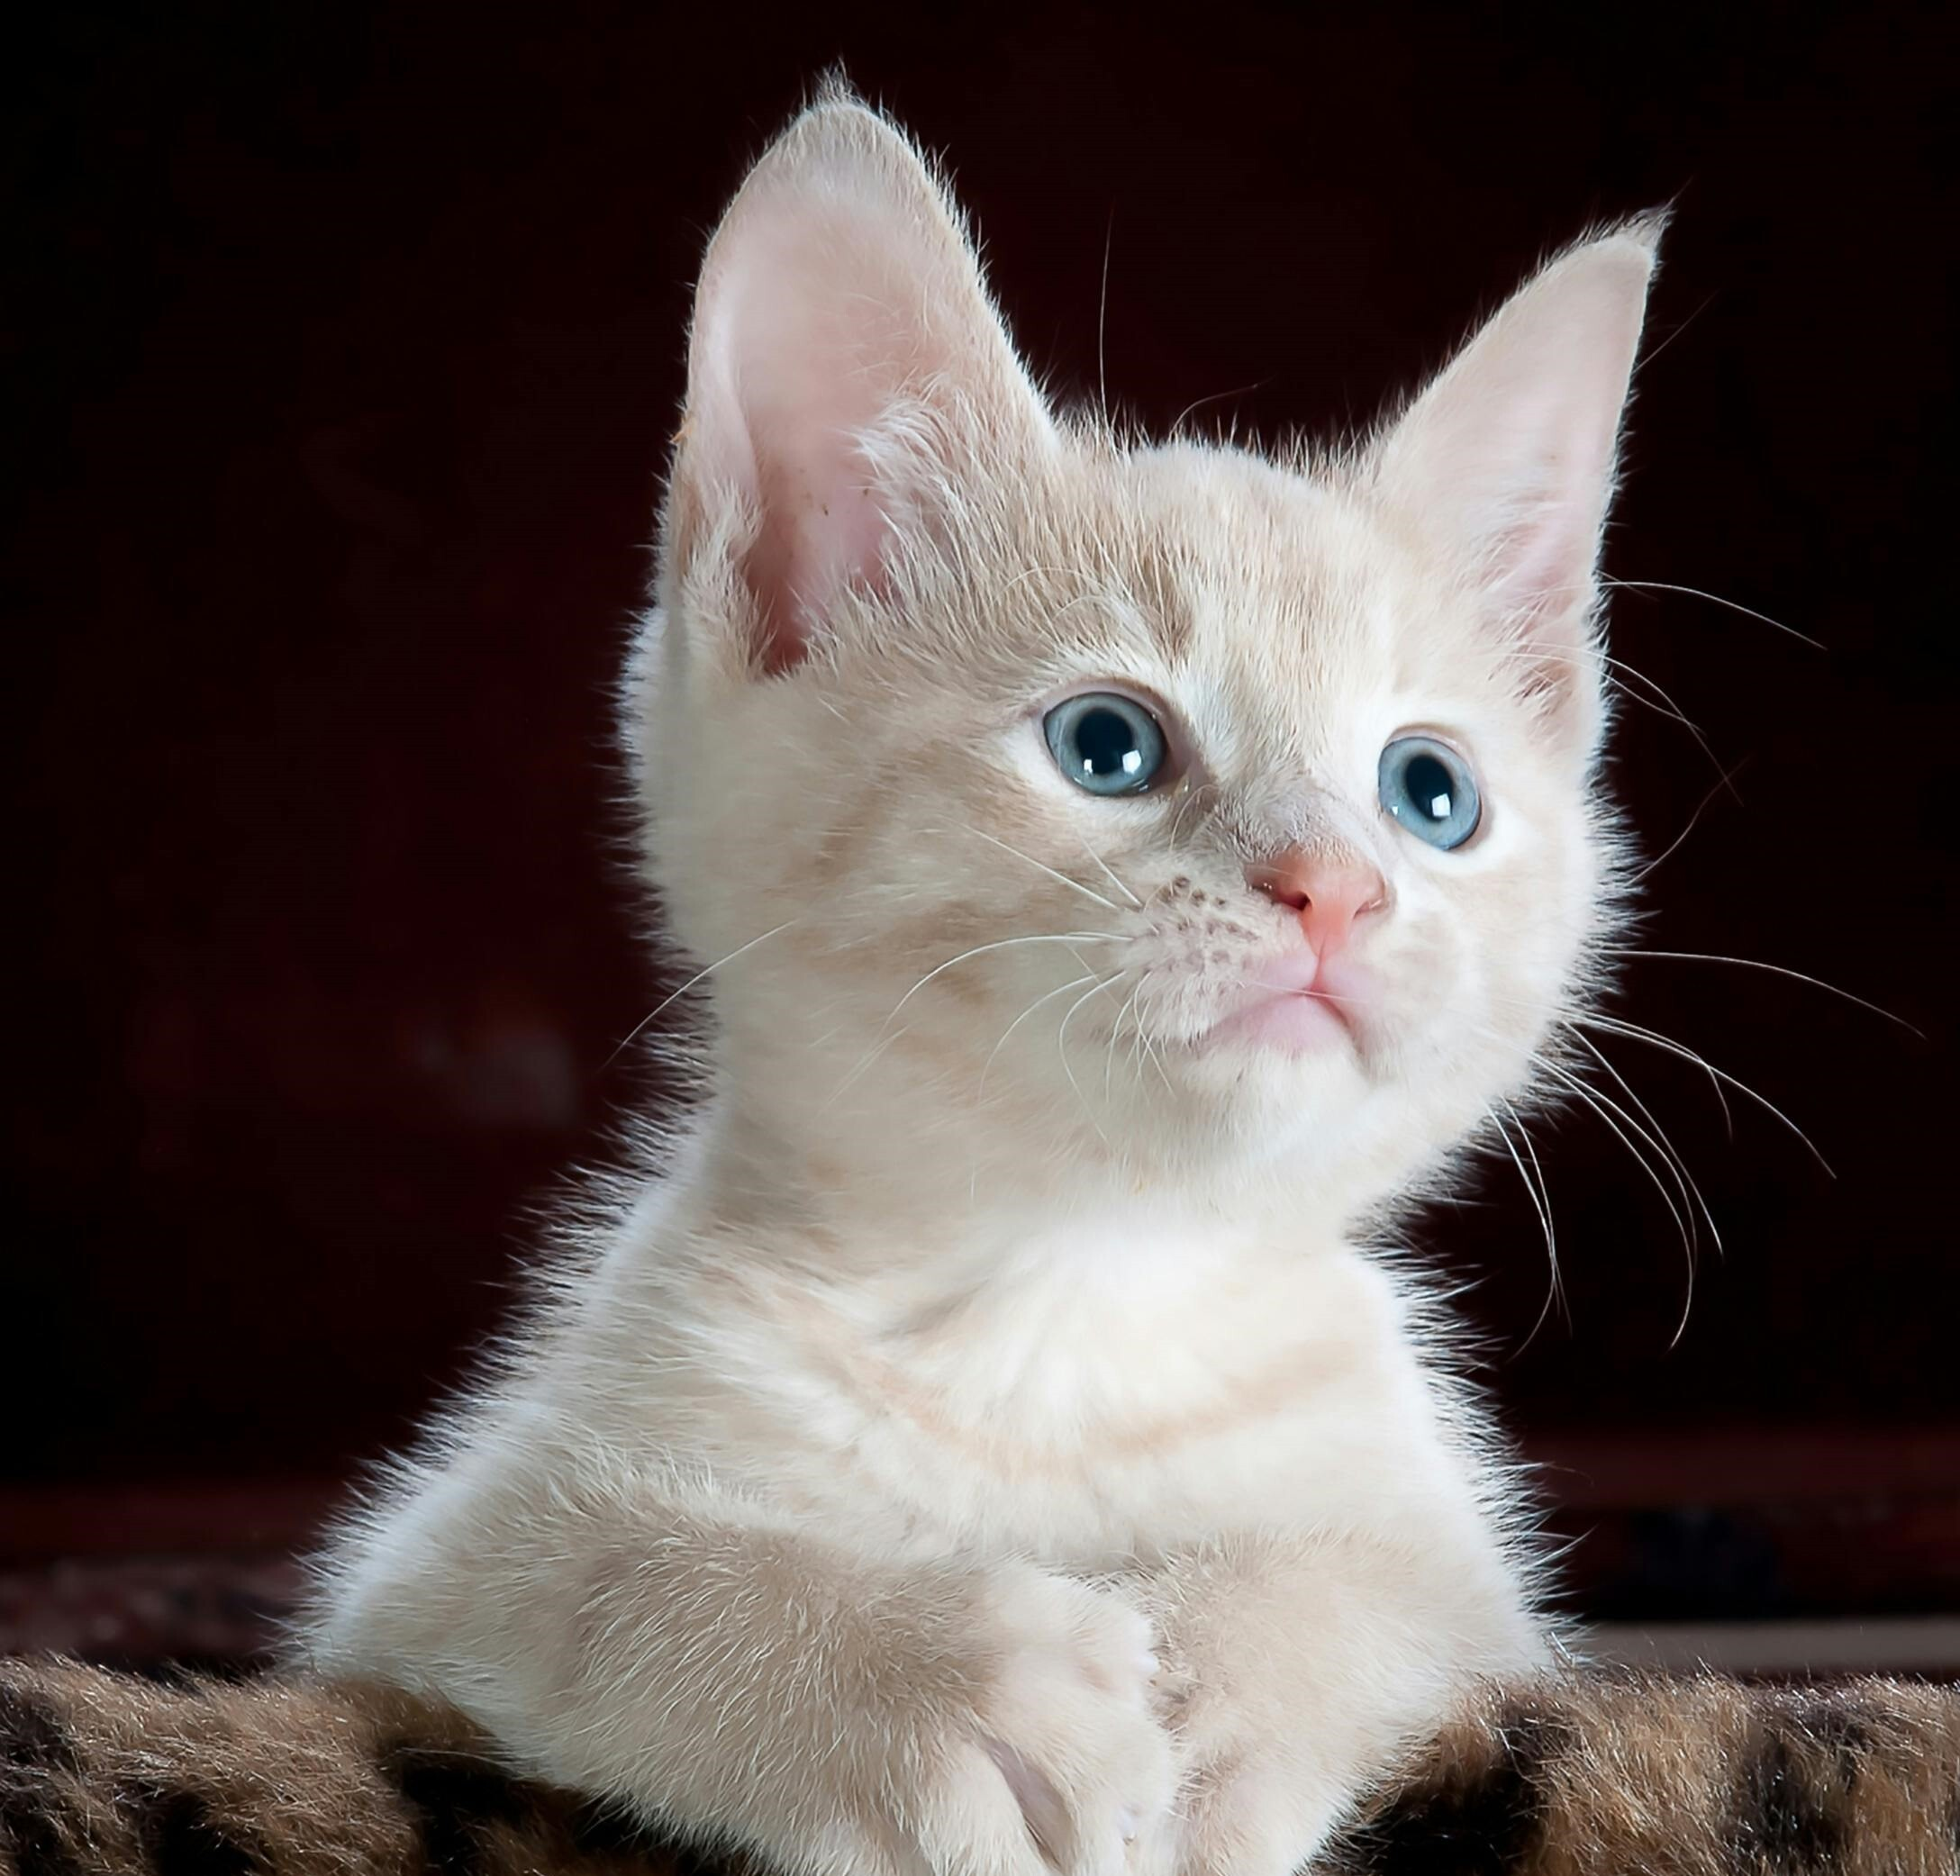

1/1 [==============================] - 0s 44ms/step
[[ 4.325979  -6.0683975]]
0
The image represents a Cat


In [106]:
input_image_path = input('Path of the image to be predicted: ')

input_image = cv2.imread(input_image_path)

cv2_imshow(input_image) #print image

input_image_resize = cv2.resize(input_image, (224,224))

input_image_scaled = input_image_resize/255

image_reshaped = np.reshape(input_image_scaled, [1,224,224,3])

input_prediction = model.predict(image_reshaped)

print(input_prediction)

input_pred_label = np.argmax(input_prediction)

print(input_pred_label)

if input_pred_label == 0:
  print('The image represents a Cat')

else:
  print('The image represents a Dog')